# 综合题 · MLP 拟合 2D 函数（第 4 章全章 · 一轮交付件「动手实践」）

> 题型：**迁移 / 动手实践**——用 MLP 拟合一个非线性 2D 函数，观察「线性拟合不了 → 加隐藏层就拟合了」。
> 这是一轮交付件：做完后本文件可直接提交（对应一轮「动手实践」+「心得」两部分）。
>
> 难度：🚀 挑战
> 做题流程：按第一步 → 第七步补全 TODO（共 5 处），每步跑出结果再继续；做完看 `solutions/综合题-答案.md`。

## 第一步 · 目标函数与 3D 曲面

目标函数：f(x₁, x₂) = sin(x₁) · cos(x₂)，定义在 [−3, 3]² 上。
先运行画图，观察它的形状——它是**高度非线性**的（有峰有谷），这正是线性模型拟合不了、MLP 能拟合的对象。

D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


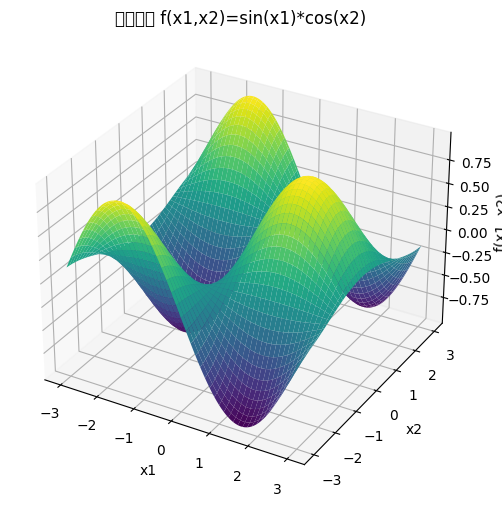

In [1]:
%matplotlib inline
import torch
import numpy as np
from torch import nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

def target(x1, x2):
    """目标函数 f(x1,x2) = sin(x1) * cos(x2)"""
    return torch.sin(x1) * torch.cos(x2)

x1 = torch.linspace(-3, 3, 100)
x2 = torch.linspace(-3, 3, 100)
X1, X2 = torch.meshgrid(x1, x2, indexing='ij')
Z = target(X1, X2)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1.numpy(), X2.numpy(), Z.numpy(), cmap='viridis')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('f(x1, x2)')
plt.title('目标函数 f(x1,x2)=sin(x1)*cos(x2)')
plt.show()

## 第二步 · 生成训练数据（TODO 1）

在 [−3, 3]² 上随机采样 2000 个点，标签 = f(x₁, x₂) + 噪声（噪声标准差 0.05）。补全数据生成。

In [12]:
def gen_data(n, noise=0.05):
    # TODO 1: 生成 X（形状 (n, 2)，取值 [-3,3]），y = target(X[:,0], X[:,1]) 加噪声，返回 (X, y.reshape(-1,1))
    # 提示: torch.rand(n, 2) * 6 - 3 得到 [-3,3] 的随机点
    X = torch.rand(n, 2) * 6 - 3
    y = target(X[:, 0], X[:, 1]) + torch.normal(0, noise, (n,))
    return (X, y.reshape(-1, 1))

X, y = gen_data(2000)
print('X 形状:', list(X.shape), ' y 形状:', list(y.shape))

X 形状: [2000, 2]  y 形状: [2000, 1]


In [8]:
help(torch.randn)

Help on built-in function randn in module torch:

randn(...)
    randn(*size, *, generator=None, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False, pin_memory=False) -> Tensor
    
    
    Returns a tensor filled with random numbers from a normal distribution
    with mean `0` and variance `1` (also called the standard normal
    distribution).
    
    .. math::
        \text{out}_{i} \sim \mathcal{N}(0, 1)
    
    For complex dtypes, the tensor is i.i.d. sampled from a `complex normal distribution`_ with zero mean and
    unit variance as
    
    .. math::
        \text{out}_{i} \sim \mathcal{CN}(0, 1)
    
    This is equivalent to separately sampling the real :math:`(\operatorname{Re})` and imaginary
    :math:`(\operatorname{Im})` part of :math:`\text{out}_i` as
    
    .. math::
        \operatorname{Re}(\text{out}_{i}) \sim \mathcal{N}(0, \frac{1}{2}),\quad
        \operatorname{Im}(\text{out}_{i}) \sim \mathcal{N}(0, \frac{1}{2})
    
    The shap

In [2]:
help(target)

Help on function target in module __main__:

target(x1, x2)
    目标函数 f(x1,x2) = sin(x1) * cos(x2)



## 第三步 · 定义 MLP（TODO 2）

一个 2 输入 → 1 输出的 MLP，中间两层隐藏层 + ReLU。补全网络结构。
先预测：如果只有 `nn.Linear(2, 1)`（线性模型），能拟合 sin·cos 吗？为什么？

In [4]:
def make_net():
    # TODO 2: nn.Sequential，2 → 64 → 64 → 1，中间用 nn.ReLU() 激活
    MLP = nn.Sequential(nn.Linear(2, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, 1))
    return MLP

## 第四步 · 训练循环（TODO 3）

用 Adam 训练，记录每 100 个 epoch 的平均损失。补全训练循环。

In [5]:
def train_net(net, X, y, lr=0.01, num_epochs=500):
    loss = nn.MSELoss()
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    history = []
    # TODO 3: 补全训练循环（zero_grad → backward → step），每 100 epoch 记录一次平均损失到 history
    loss_sum = 0
    for epoch in range(num_epochs):
        y_hat = net(X)
        l = loss(y_hat, y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
        loss_sum += l
        if (epoch + 1) % 100 == 0:
            history.append(float(loss_sum / 100))
            loss_sum = 0
    print(f'最终损失: {history[-1]:.6f}')
    return history

### 训练并对比预测曲面 vs 真实曲面

最终损失: 0.002893


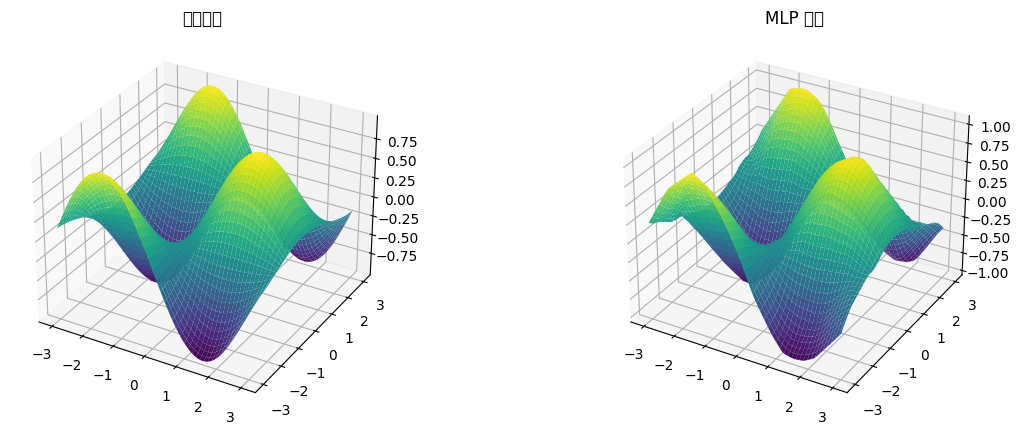

In [11]:
net = make_net()
history = train_net(net, X, y)

# 在网格上预测，画曲面
with torch.no_grad():
    grid = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=1)
    Z_pred = net(grid).reshape(100, 100)

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X1.numpy(), X2.numpy(), Z.numpy(), cmap='viridis')
ax1.set_title('真实函数')
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X1.numpy(), X2.numpy(), Z_pred.numpy(), cmap='viridis')
ax2.set_title('MLP 拟合')
plt.show()

## 第五步 · 加噪声，观察拟合函数还是拟合噪声

先预测：如果把噪声标准差从 0.05 加到 0.5，MLP 的预测曲面会怎样？它会拟合出「真实的 sin·cos」还是「带着噪声的毛刺」？

带着噪声的毛刺

最终损失: 0.244735


D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22122 (\N{CJK UNIFIED IDEOGRAPH-566A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22768 (\N{CJK UNIFIED IDEOGRAPH-58F0}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\an

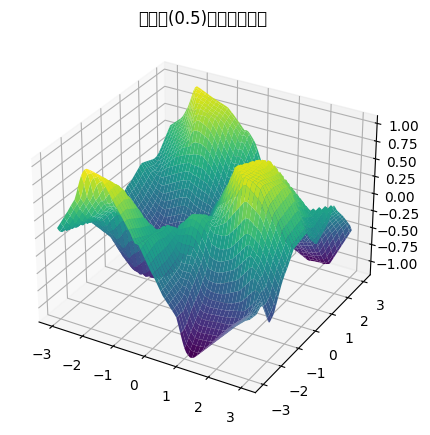

In [13]:
# 用大噪声重新训练，观察预测曲面
X_noisy, y_noisy = gen_data(2000, noise=0.5)
net_noisy = make_net()
train_net(net_noisy, X_noisy, y_noisy, num_epochs=500)

with torch.no_grad():
    grid = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=1)
    Z_noisy = net_noisy(grid).reshape(100, 100)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1.numpy(), X2.numpy(), Z_noisy.numpy(), cmap='viridis')
ax.set_title('大噪声(0.5)下的拟合结果')
plt.show()

## 第五步（续）· 尝试正则化组件：weight_decay 与 Dropout

第五步看到：大噪声下 MLP 会「拟合噪声」，预测曲面出毛刺（过拟合）。ch04 学的两个正则化工具—— **权重衰减（weight_decay）** 和 **Dropout**——正是治这个的。

用大噪声数据（noise=0.5）训练三个模型，比较它们对「干净真函数」的拟合误差（MSE 越小 = 越能抵抗噪声、找回真函数）：

| 模型 | 手段 |
|---|---|
| 基线（无正则） | 无 |
| weight_decay=0.001 | 优化器加 weight_decay 参数 |
| Dropout=0.2 | 网络里加 nn.Dropout(0.2) |

先预测：哪个模型对干净函数的误差最小？为什么？过强的正则化会怎样？

**【你的预测】**

In [28]:
# 带 Dropout 的网络（Dropout 只在训练时生效，评估时 net.eval() 自动关闭）
def make_net_dropout():
    return nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Dropout(0.2),
                         nn.Linear(64, 64), nn.ReLU(), nn.Dropout(0.2),
                         nn.Linear(64, 1))

# 干净网格（无噪声）作为「测试集」，衡量模型对真函数的拟合误差
grid = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=1)   # X1/X2 来自第一步
y_clean = target(X1, X2).reshape(-1, 1)

def clean_mse(net):
    net.eval()
    with torch.no_grad():
        pred = net(grid)
    net.train()
    return float(((pred - y_clean) ** 2).mean())

In [29]:
def train_with_reg(net, X, y, wd=0.0, lr=0.01, num_epochs=500):
    # TODO 综合题·正则化: 训练循环，优化器用 Adam 并把 weight_decay=wd 传进去
    # 提示: 开头 net.train() 确保 Dropout 生效；循环结构与 train_net 一样
    net.train()
    loss = nn.MSELoss()
    trainer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay = wd)
    history = []
    for epoch in range(num_epochs):
        y_hat = net(X)
        l = loss(y_hat, y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
        history.append(float(l))

In [30]:
try:
    X_noisy, y_noisy = gen_data(2000, noise=0.5)
    models = {
        '基线（无正则）': make_net(),
        'weight_decay=0.001': make_net(),
        'Dropout=0.2': make_net_dropout(),
    }
    results = {}
    for name, net in models.items():
        wd = 0.001 if 'weight_decay' in name else 0.0
        train_with_reg(net, X_noisy, y_noisy, wd=wd)
        results[name] = clean_mse(net)
        print(f'{name:20s} 干净函数 MSE = {results[name]:.4f}')
except NotImplementedError as e:
    print(f'⚠ {e}')

基线（无正则）              干净函数 MSE = 0.0136
weight_decay=0.001   干净函数 MSE = 0.0091
Dropout=0.2          干净函数 MSE = 0.0114


C:\Users\moneyforever\AppData\Local\Temp\ipykernel_612\4216329605.py:10: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from current font.
  plt.tight_layout()
C:\Users\moneyforever\AppData\Local\Temp\ipykernel_612\4216329605.py:10: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  plt.tight_layout()
C:\Users\moneyforever\AppData\Local\Temp\ipykernel_612\4216329605.py:10: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  plt.tight_layout()
C:\Users\moneyforever\AppData\Local\Temp\ipykernel_612\4216329605.py:10: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from current font.
  plt.tight_layout()
C:\Users\moneyforever\AppData\Local\Temp\ipykernel_612\4216329605.py:10: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from current font.
  plt.tight_layout()
C:\Users\moneyforever\AppData\Local\Temp\ipykernel_612\4216329605.py:10: UserWarning: Glyph 21017 (\N{CJK

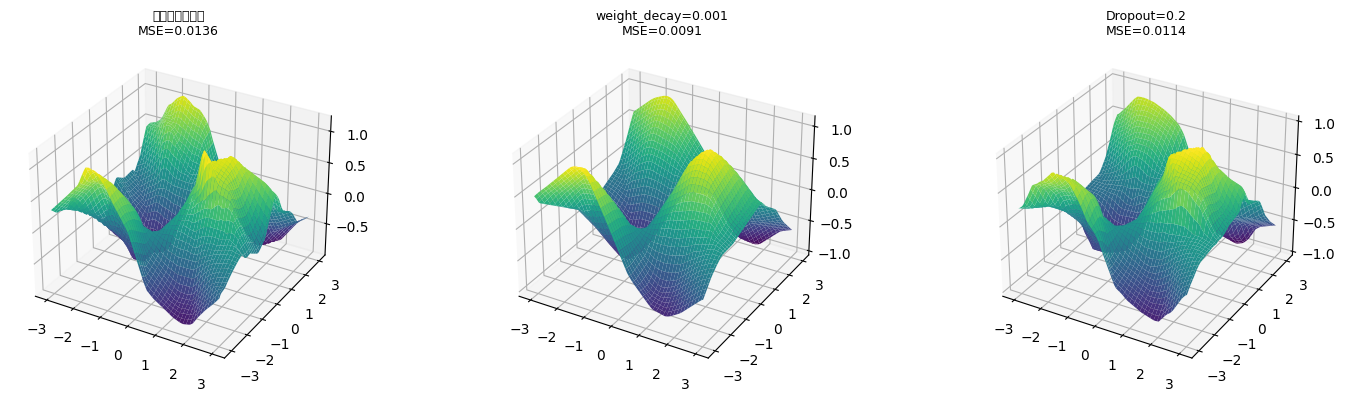

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), subplot_kw={'projection': '3d'})
for ax, name in zip(axes, models.keys()):
    net = models[name]
    net.eval()
    with torch.no_grad():
        Zp = net(grid).reshape(100, 100)
    net.train()
    ax.plot_surface(X1.numpy(), X2.numpy(), Zp.numpy(), cmap='viridis')
    ax.set_title(f'{name}\nMSE={results[name]:.4f}', fontsize=9)
plt.tight_layout()
plt.show()

## 第六步 · 学习率对比（TODO 4）

分别用 lr ∈ {0.1, 0.01, 0.001, 0.0001}（SGD）训练，画损失曲线。先预测：哪个 lr 收敛最快？哪个会发散/震荡？
（注意：这节用 SGD 而不是 Adam，因为 SGD 对 lr 更敏感，能更清楚地看出差异）

lr = 0.1, lr = 0.1

In [18]:
def train_sgd(lr, num_epochs=800):
    net = make_net()
    loss = nn.MSELoss()
    trainer = torch.optim.SGD(net.parameters(), lr=lr)
    history = []
    for epoch in range(num_epochs):
        # TODO 4: 用 SGD 训练一轮并记录每个 epoch 的平均损失
        y_hat = net(X)
        l = loss(y_hat, y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
        history.append(float(l))
    print(f'lr={lr}: 最终损失 {history[-1]:.6f}')
    return history

C:\Users\moneyforever\AppData\Local\Temp\ipykernel_612\3671778143.py:13: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  history.append(float(l))


lr=0.1: 最终损失 0.009852
lr=0.01: 最终损失 0.027802
lr=0.001: 最终损失 0.184972
lr=0.0001: 最终损失 0.243877


D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20064 (\N{CJK UNIFIED IDEOGRAPH-4E60}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\an

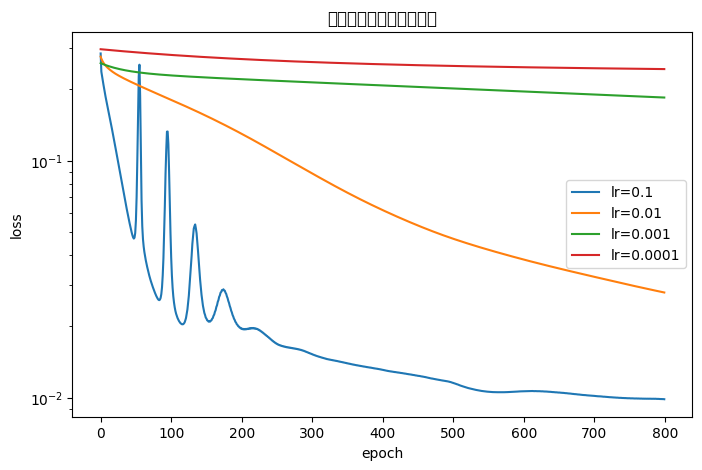

In [19]:
histories = {}
for lr in [0.1, 0.01, 0.001, 0.0001]:
    histories[lr] = train_sgd(lr)

plt.figure(figsize=(8, 5))
for lr, hist in histories.items():
    plt.plot(hist, label=f'lr={lr}')
plt.xlabel('epoch'); plt.ylabel('loss')
plt.yscale('log')
plt.legend()
plt.title('不同学习率下的损失曲线')
plt.show()

## 第七步 · 外推实验（TODO 5）

模型只在 [−2, 2]² 上训练，却在 [−5, 5]² 上预测。先预测：MLP 在训练范围之外的表现会怎样？为什么？

（这是 MLP 的一个经典缺陷：它「记住」了训练范围内的函数，但**没有外推能力**，超出范围后预测会乱掉。）

最终损失: 0.002462


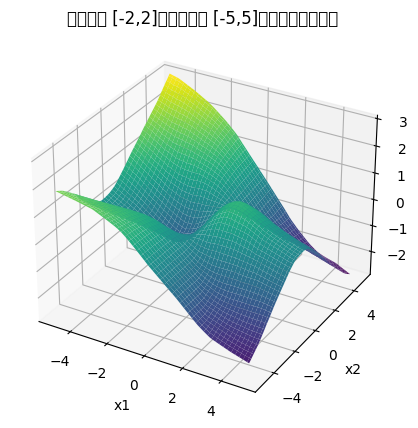

In [27]:
# 只在 [-2,2]^2 训练
X_small = torch.rand(2000, 2) * 4 - 2   # [-2,2]
y_small = target(X_small[:, 0], X_small[:, 1]).reshape(-1, 1) + torch.normal(0, 0.05, (2000, 1))
net_ext = make_net()
train_net(net_ext, X_small, y_small, num_epochs=500)

# 在 [-5,5]^2 预测
x1e = torch.linspace(-5, 5, 100)
x2e = torch.linspace(-5, 5, 100)
X1e, X2e = torch.meshgrid(x1e, x2e, indexing='ij')
with torch.no_grad():
    # TODO 5: 在 X1e/X2e 网格上预测 Z_ext，画曲面
    Z_ext = net_ext(torch.stack([X1e.reshape(-1), X2e.reshape(-1)], dim=1)).reshape(100, 100)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1e.numpy(), X2e.numpy(), Z_ext.numpy(), cmap='viridis')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('训练范围 [-2,2]，预测范围 [-5,5]（观察外推失败）')
plt.show()

In [20]:
help(torch.linspace)

Help on built-in function linspace in module torch:

linspace(...)
    linspace(start, end, steps, *, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False) -> Tensor
    
    Creates a one-dimensional tensor of size :attr:`steps` whose values are evenly
    spaced from :attr:`start` to :attr:`end`, inclusive. That is, the value are:
    
    .. math::
        (\text{start},
        \text{start} + \frac{\text{end} - \text{start}}{\text{steps} - 1},
        \ldots,
        \text{start} + (\text{steps} - 2) * \frac{\text{end} - \text{start}}{\text{steps} - 1},
        \text{end})
    
    
    From PyTorch 1.11 linspace requires the steps argument. Use steps=100 to restore the previous behavior.
    
    Args:
        start (float or Tensor): the starting value for the set of points. If `Tensor`, it must be 0-dimensional
        end (float or Tensor): the ending value for the set of points. If `Tensor`, it must be 0-dimensional
        steps (int): size of the cons

## 第八步 · 心得（一轮「心得」部分，写一段即可）

先写你的观察，再对照答案文件：

1. 学习率、批次大小、网络深度三者对训练的影响，你的直观感受是什么？
2. 「加噪声」实验说明模型在拟合什么？什么时候它会去拟合噪声？
3. 「外推」实验说明 MLP 的什么缺陷？

**【你的心得】**
1. lr越大收敛越快但是更加容易震荡，lr越小与之相反；batchsize大小应该会影响训练的精度；深度会影响训练的速度，但是拟合效果更好

2. 噪声，过拟合

3. MLP 没有「外推能力」——它在训练范围内拟合得很好，但超出范围后 ReLU 网络是分段的线性函数，会沿着学到的斜率无限延伸，完全偏离真实的周期函数。这是神经网络的一个经典缺陷。

## 提交清单（对应一轮「动手实践」+「心得」）

- [ ] 绘制目标函数 3D 曲面
- [ ] MLP 拟合（第二步~第四步）
- [ ] 加噪声观察（第五步）
- [ ] 不同学习率的损失曲线（第六步）
- [ ] 扩大取值范围观察外推（第七步）
- [ ] 心得（第八步）